In [3]:
import pandas as pd

raspbugs = pd.read_json("../mutation/raspbugs.json")
raspbugs.head()

,program_name,program_source_before,diff,program_source_after,operators,job_id,mutation_order,execution_result,mutation_object,result_object,gbpr_accuracy
0,hist,from tracr.rasp import rasp\n\n\ndef make_hist...,--- mutation diff ---\n--- asource/hist.py\n++...,from tracr.rasp import rasp\n\n\ndef make_hist...,[operators/replace-rasp-comparison],2a722d5d5449441fad93f98c73c633a2,1,"{'status': 'BUGGY_MODEL', 'accuracy': 0.0}","{'job_id': '2a722d5d5449441fad93f98c73c633a2',...","{'worker_outcome': 'normal', 'output': '======...",0.0160
1,hist,from tracr.rasp import rasp\n\n\ndef make_hist...,--- mutation diff ---\n--- asource/hist.py\n++...,from tracr.rasp import rasp\n\n\ndef make_hist...,[operators/replace-rasp-comparison],ee8c6dd459324fa4a1269e1b30635bd5,1,"{'status': 'BUGGY_MODEL', 'accuracy': 0.0}","{'job_id': 'ee8c6dd459324fa4a1269e1b30635bd5',...","{'worker_outcome': 'normal', 'output': '======...",0.0170
2,hist,from tracr.rasp import rasp\n\n\ndef make_hist...,--- mutation diff ---\n--- asource/hist.py\n++...,from tracr.rasp import rasp\n\n\ndef make_hist...,[operators/replace-rasp-comparison],ca28aa28e26c4e67b9987911b50b8ae4,1,"{'status': 'BUGGY_MODEL', 'accuracy': 0.0}","{'job_id': 'ca28aa28e26c4e67b9987911b50b8ae4',...","{'worker_outcome': 'normal', 'output': '======...",1.0000
3,hist,from tracr.rasp import rasp\n\n\ndef make_hist...,--- mutation diff ---\n--- asource/hist.py\n++...,from tracr.rasp import rasp\n\n\ndef make_hist...,[operators/replace-rasp-comparison],cf0cecafd2aa49a49bba26146d55b1ff,1,"{'status': 'BUGGY_MODEL', 'accuracy': 0.0}","{'job_id': 'cf0cecafd2aa49a49bba26146d55b1ff',...","{'worker_outcome': 'normal', 'output': '======...",0.0192
4,hist,from tracr.rasp import rasp\n\n\ndef make_hist...,--- mutation diff ---\n--- asource/hist.py\n++...,from tracr.rasp import rasp\n\n\ndef make_hist...,[operators/replace-rasp-comparison],915a38d1da254c769c958982c210c27b,1,"{'status': 'BUGGY_MODEL', 'accuracy': 0.0}","{'job_id': '915a38d1da254c769c958982c210c27b',...","{'worker_outcome': 'normal', 'output': '======...",1.0000


In [21]:
import os, glob, json
import pandas as pd

def collect_rows(dir: str) -> pd.DataFrame:
    """
    Scan `dir` for files named  `{program_name}_{job_id}.jsonl`
    and return a DataFrame with one row per file.
    """
    records = []
    for fpath in glob.glob(os.path.join(dir, "*.jsonl")):
        with open(fpath, "r") as fp:
            # every file has exactly one JSON-line
            rec = json.loads(fp.readline())
            records.append(rec)

    df = pd.DataFrame.from_records(records)
    return df


evaluation_dir = "results_full/gpt-4.1-2025-04-14/evaluation/mutation_results"
eval_df = collect_rows(evaluation_dir)
eval_df.head()

patches_dir = "results_full/gpt-4.1-2025-04-14/patches"
patches_df = collect_rows(patches_dir)
patches_df.head()

merged = patches_df.merge(
    eval_df,
    on=["program_name", "job_id", "mutation_id"],
    how="left",
    suffixes=("", "_eval")
)
print(merged.shape)
merged.head()

(1466, 8)


,mutation_id,program_name,job_id,responses,prompt,model_name,temperature,patch_results
0,0532b1914bc2417486ac590b6672afb5,hist,0532b1914bc2417486ac590b6672afb5,[{'id': 'chatcmpl-C1KpGdigBz7Ix3d2HkIHfsVkgRbg...,# Introduction to Task:\nYour assignment is to...,gpt-4.1-2025-04-14,0.2,"[{'patch_index': 0, 'passed': True, 'error': N..."
1,0b0495fcab1c4e9d830e5541122891b7,hist,0b0495fcab1c4e9d830e5541122891b7,[{'id': 'chatcmpl-C1KpcrrQXJMV2reeDQQzCZKKpwrn...,# Introduction to Task:\nYour assignment is to...,gpt-4.1-2025-04-14,0.2,"[{'patch_index': 0, 'passed': True, 'error': N..."
2,106176312e2447d190c2dc7d6b2ea4bb,hist,106176312e2447d190c2dc7d6b2ea4bb,[{'id': 'chatcmpl-C1KpPXCvkv7zBjjLfLfC5a5dalJR...,# Introduction to Task:\nYour assignment is to...,gpt-4.1-2025-04-14,0.2,"[{'patch_index': 0, 'passed': True, 'error': N..."
3,24c5f9d08ea2495e80a9f1fda797bc89,hist,24c5f9d08ea2495e80a9f1fda797bc89,[{'id': 'chatcmpl-C1KuBKUynI92I22ZdekfGSNGxA5U...,# Introduction to Task:\nYour assignment is to...,gpt-4.1-2025-04-14,0.2,"[{'patch_index': 0, 'passed': True, 'error': N..."
4,26c89bc5b0624fb0b79f91ae8422a9d0,hist,26c89bc5b0624fb0b79f91ae8422a9d0,[{'id': 'chatcmpl-C1KucoIEiMPBqa5F1qh3lawHb3Rm...,# Introduction to Task:\nYour assignment is to...,gpt-4.1-2025-04-14,0.2,"[{'patch_index': 0, 'passed': True, 'error': N..."


In [22]:
merged = raspbugs.merge(
    merged,
    on=["program_name", "job_id"],
    how="left",
    suffixes=("", "_eval")
)
merged.head()

,program_name,program_source_before,diff,program_source_after,operators,job_id,mutation_order,execution_result,mutation_object,result_object,gbpr_accuracy,mutation_id,responses,prompt,model_name,temperature,patch_results
0,hist,from tracr.rasp import rasp\n\n\ndef make_hist...,--- mutation diff ---\n--- asource/hist.py\n++...,from tracr.rasp import rasp\n\n\ndef make_hist...,[operators/replace-rasp-comparison],2a722d5d5449441fad93f98c73c633a2,1,"{'status': 'BUGGY_MODEL', 'accuracy': 0.0}","{'job_id': '2a722d5d5449441fad93f98c73c633a2',...","{'worker_outcome': 'normal', 'output': '======...",0.0160,2a722d5d5449441fad93f98c73c633a2,[{'id': 'chatcmpl-C1KnsvaXUDuZeqlqsNBfVDhiSMpc...,# Introduction to Task:\nYour assignment is to...,gpt-4.1-2025-04-14,0.2,"[{'patch_index': 0, 'passed': True, 'error': N..."
1,hist,from tracr.rasp import rasp\n\n\ndef make_hist...,--- mutation diff ---\n--- asource/hist.py\n++...,from tracr.rasp import rasp\n\n\ndef make_hist...,[operators/replace-rasp-comparison],ee8c6dd459324fa4a1269e1b30635bd5,1,"{'status': 'BUGGY_MODEL', 'accuracy': 0.0}","{'job_id': 'ee8c6dd459324fa4a1269e1b30635bd5',...","{'worker_outcome': 'normal', 'output': '======...",0.0170,ee8c6dd459324fa4a1269e1b30635bd5,[{'id': 'chatcmpl-C1KnwBqbF2ehU1s7q3dJId7FtCv7...,# Introduction to Task:\nYour assignment is to...,gpt-4.1-2025-04-14,0.2,"[{'patch_index': 0, 'passed': True, 'error': N..."
2,hist,from tracr.rasp import rasp\n\n\ndef make_hist...,--- mutation diff ---\n--- asource/hist.py\n++...,from tracr.rasp import rasp\n\n\ndef make_hist...,[operators/replace-rasp-comparison],ca28aa28e26c4e67b9987911b50b8ae4,1,"{'status': 'BUGGY_MODEL', 'accuracy': 0.0}","{'job_id': 'ca28aa28e26c4e67b9987911b50b8ae4',...","{'worker_outcome': 'normal', 'output': '======...",1.0000,ca28aa28e26c4e67b9987911b50b8ae4,[{'id': 'chatcmpl-C1KnjyFhK53Uc8tHPm7nfUfccfwe...,# Introduction to Task:\nYour assignment is to...,gpt-4.1-2025-04-14,0.2,"[{'patch_index': 0, 'passed': True, 'error': N..."
3,hist,from tracr.rasp import rasp\n\n\ndef make_hist...,--- mutation diff ---\n--- asource/hist.py\n++...,from tracr.rasp import rasp\n\n\ndef make_hist...,[operators/replace-rasp-comparison],cf0cecafd2aa49a49bba26146d55b1ff,1,"{'status': 'BUGGY_MODEL', 'accuracy': 0.0}","{'job_id': 'cf0cecafd2aa49a49bba26146d55b1ff',...","{'worker_outcome': 'normal', 'output': '======...",0.0192,cf0cecafd2aa49a49bba26146d55b1ff,[{'id': 'chatcmpl-C1KneHAHfIjAnjv3noV9Q8mH8EiF...,# Introduction to Task:\nYour assignment is to...,gpt-4.1-2025-04-14,0.2,"[{'patch_index': 0, 'passed': True, 'error': N..."
4,hist,from tracr.rasp import rasp\n\n\ndef make_hist...,--- mutation diff ---\n--- asource/hist.py\n++...,from tracr.rasp import rasp\n\n\ndef make_hist...,[operators/replace-rasp-comparison],915a38d1da254c769c958982c210c27b,1,"{'status': 'BUGGY_MODEL', 'accuracy': 0.0}","{'job_id': '915a38d1da254c769c958982c210c27b',...","{'worker_outcome': 'normal', 'output': '======...",1.0000,915a38d1da254c769c958982c210c27b,[{'id': 'chatcmpl-C1KnOIi82GsHDVs4ZfmnG3YYERoy...,# Introduction to Task:\nYour assignment is to...,gpt-4.1-2025-04-14,0.2,"[{'patch_index': 0, 'passed': True, 'error': N..."


In [52]:
from evaluate_patches import pass_at_k

def compute_pass_at_k(df: pd.DataFrame, k: int) -> float:
    """
    Compute the pass@k for a given DataFrame.
    """
    # we care about the eval results stored in the column `patch_results`, where each patch contains a `passed` field
    total_patches = sum(len(patch_results) for patch_results in df["patch_results"])
    correct_patches = sum(
        1
        for patch_results in df["patch_results"]
        for patch in patch_results
        if patch["passed"]
    )
    return pass_at_k(total_patches, correct_patches, k)


def compute_pass_at_k_with_threshold(df: pd.DataFrame, k: int, threshold: float) -> float:
    """
    Compute the pass@k for a given DataFrame.
    """
    # we care about the eval results stored in the column `patch_results`, where each patch contains a `passed` field
    total_patches = sum(len(patch_results) for patch_results in df["patch_results"])
    correct_patches = sum(
        1
        for patch_results in df["patch_results"]
        for patch in patch_results
        if patch["accuracy"] is not None and patch["accuracy"] >= (1.0 - threshold)
    )
    return pass_at_k(total_patches, correct_patches, k)


print(compute_pass_at_k_with_threshold(merged, 1, 0.1))
print(compute_pass_at_k_with_threshold(merged, 1, 0.01))
print(compute_pass_at_k_with_threshold(merged, 1, 0.001))
print(compute_pass_at_k(merged, 1))

0.3459754433833542
0.34399727148703896
0.3437244201909979
0.34345156889495476


In [ ]:
import pandas as pd

def summarize_pass_rates_by_mutation_order(merged_df: pd.DataFrame, thresholds=[0.0, 0.001, 0.01, 0.1]):
    """
    Print a NeurIPS rebuttal-ready textual table of GBPR and LLM pass@1 rates by mutation order and threshold.
    Also prints the values for all mutation orders combined.
    """
    mutation_orders = sorted(merged_df["mutation_order"].unique())
    lines = []
    for threshold in thresholds:
        header = (
            f"\n=== Pass@1 Results by Mutation Order (accuracy >= {1.0-threshold:.3f}) ===\n"
            f"{'Mutation Order':<16} | {'GBPR pass@1':<14} | {'LLM pass@1':<14}\n"
            + "-"*50
        )
        lines.append(header)
        for mutation_order in mutation_orders:
            df = merged_df[merged_df["mutation_order"] == mutation_order]
            total = df.shape[0]
            gbpr_over_threshold = df[df["gbpr_accuracy"] >= (1.0 - threshold)].shape[0]
            gbpr_pass_rate = gbpr_over_threshold / total if total > 0 else float('nan')
            llm_pass_rate = compute_pass_at_k_with_threshold(df, 1, threshold)
            lines.append(
                f"{str(mutation_order):<16} | {gbpr_pass_rate:.3f}         | {llm_pass_rate:.3f}"
            )

        # All mutation orders combined
        df_all = merged_df
        total_all = df_all.shape[0]
        gbpr_over_threshold_all = df_all[df_all["gbpr_accuracy"] >= (1.0 - threshold)].shape[0]
        gbpr_pass_rate_all = gbpr_over_threshold_all / total_all if total_all > 0 else float('nan')
        llm_pass_rate_all = compute_pass_at_k_with_threshold(df_all, 1, threshold)
        lines.append("-"*50)
        lines.append(
            f"{'ALL':<16} | {gbpr_pass_rate_all:.3f}         | {llm_pass_rate_all:.3f}"
        )
    print("\n".join(lines))

summarize_pass_rates_by_mutation_order(merged, thresholds=[0.0, 0.001, 0.01])


=== Pass@1 Results by Mutation Order (accuracy >= 1.000) ===
Mutation Order   | GBPR pass@1    | LLM pass@1    
--------------------------------------------------
1                | 0.078         | 0.277
2                | 0.116         | 0.401
3                | 0.106         | 0.345
4                | 0.151         | 0.341
5                | 0.067         | 0.296
--------------------------------------------------
ALL              | 0.106         | 0.343

=== Pass@1 Results by Mutation Order (accuracy >= 0.999) ===
Mutation Order   | GBPR pass@1    | LLM pass@1    
--------------------------------------------------
1                | 0.130         | 0.278
2                | 0.237         | 0.401
3                | 0.161         | 0.345
4                | 0.229         | 0.341
5                | 0.142         | 0.297
--------------------------------------------------
ALL              | 0.188         | 0.344

=== Pass@1 Results by Mutation Order (accuracy >= 0.990) ===
Mutation Order  

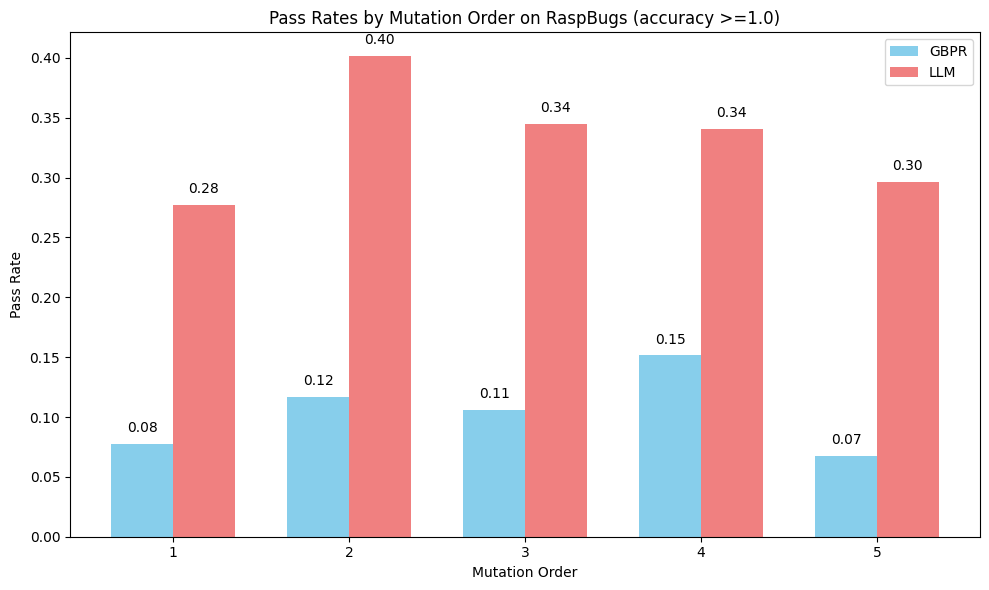

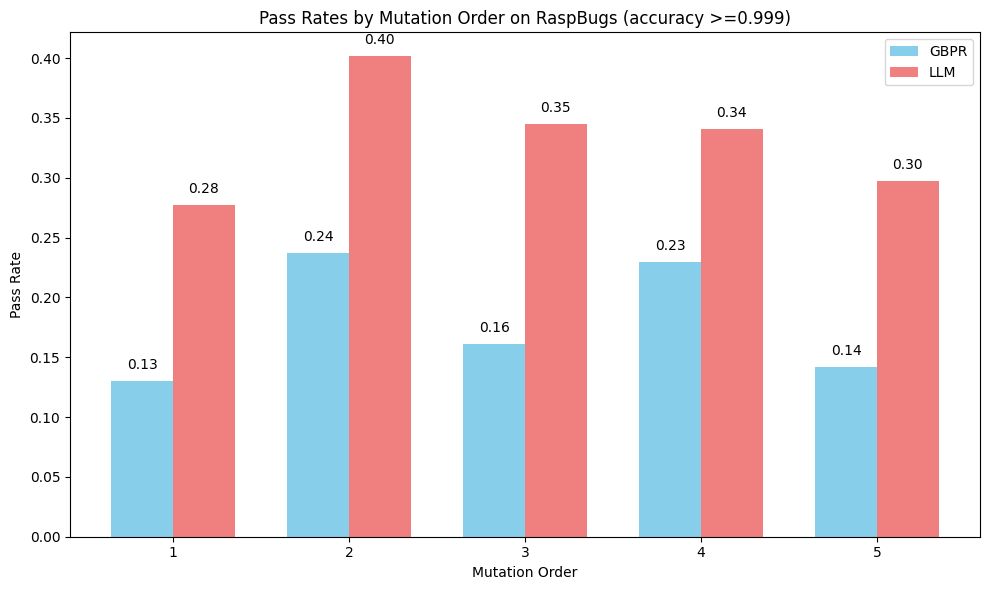

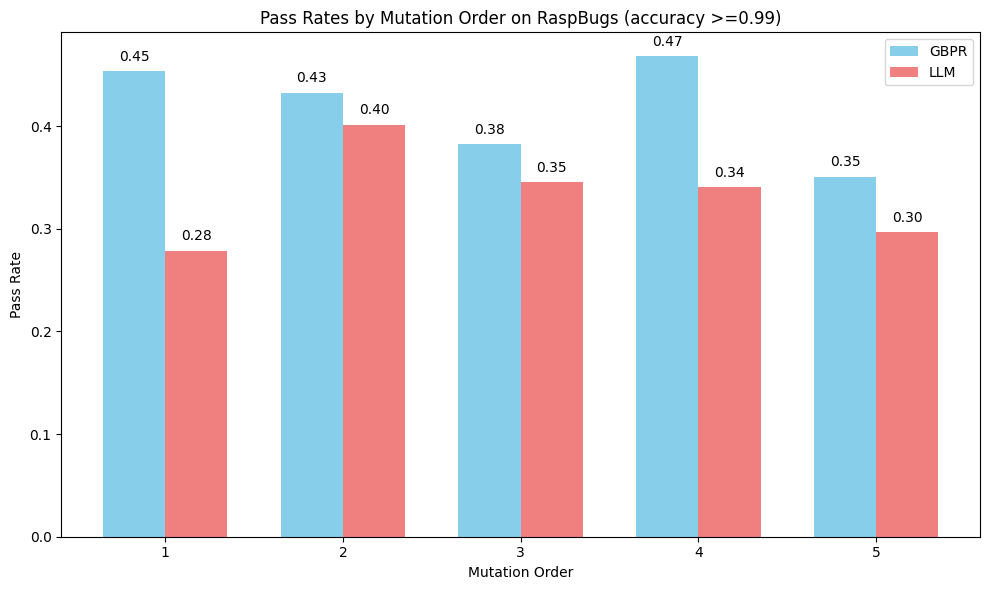

In [57]:
import matplotlib.pyplot as plt
import numpy as np

def plot_pass_rates_matplotlib(merged_df: pd.DataFrame, threshold: float):
    """
    Create a matplotlib bar plot comparing GBPR and LLM pass rates by mutation order.
    """
    mutation_orders = sorted(merged_df["mutation_order"].unique())
    gbpr_rates = []
    llm_rates = []
    
    for mutation_order in mutation_orders:
        df = merged_df[merged_df["mutation_order"] == mutation_order]
        over_threshold = df[df["gbpr_accuracy"] >= (1.0 - threshold)].shape[0]
        total = df.shape[0]
        gbpr_pass_rate = over_threshold / total
        llm_pass_rate = compute_pass_at_k_with_threshold(df, 1, threshold)
        
        gbpr_rates.append(gbpr_pass_rate)
        llm_rates.append(llm_pass_rate)
    
    x = np.arange(len(mutation_orders))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(x - width/2, gbpr_rates, width, label='GBPR', color='skyblue')
    ax.bar(x + width/2, llm_rates, width, label='LLM', color='lightcoral')
    
    ax.set_ylabel('Pass Rate')
    ax.set_xlabel('Mutation Order')
    ax.set_title(f'Pass Rates by Mutation Order on RaspBugs (accuracy >={(1.0-threshold)})')
    ax.set_xticks(x)
    ax.set_xticklabels(mutation_orders)
    ax.legend()
    
    # Add value labels on top of each bar
    for i, v in enumerate(gbpr_rates):
        ax.text(i - width/2, v + 0.01, f'{v:.2f}', ha='center')
    for i, v in enumerate(llm_rates):
        ax.text(i + width/2, v + 0.01, f'{v:.2f}', ha='center')
    
    plt.tight_layout()
    plt.show()

# Create plots for each threshold
for threshold in [0.0, 0.001, 0.01]:
    plot_pass_rates_matplotlib(merged, threshold)